In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pyEXP
pyEXP.util.getVersionInfo()


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%% This is EXP 7.9.3 %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%% Repository URL | https://github.com/EXP-code/EXP                         %
%%%%% Current branch | main                                                    %
%%%%% Current commit | 6cbd08fe546ff42ec833ecca423f46f3ba1f0aa9                %
%%%%% Compile time   | 2026-04-08 10:25:43 BST                                 %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%



In [3]:
import exptool
from exptool.io import particle

inputfile = '../Data/OUT.run0.00020'


In [4]:
# make a velocity instance

halo_vconfig = """
---
id: velocity
parameters :
  modelname: SLGridSph.model
  lmax : 2
  nmax : 6
  dof : 3
...
"""

# Construct the basis instance
#
halo_vbasis   = pyEXP.basis.VelocityBasis(halo_vconfig)
halo_vbasis   = pyEXP.basis.Basis.factory(halo_vconfig)

FieldBasis::orthoTest: worst=8.06104e-16
FieldBasis::orthoTest: worst=8.06104e-16


In [5]:
O = exptool.io.particle.Input(inputfile,'dark halo')
print(O.time)
halo_vcoef = halo_vbasis.createFromArray(O.data['m'],np.array([O.data['x'],O.data['y'],O.data['z'],O.data['vx'],O.data['vy'],O.data['vz']]), time=O.time)
halo_vcoefs = pyEXP.coefs.Coefs.makecoefs(halo_vcoef, 'dark halo')
halo_vcoefs.add(halo_vcoef)

0.20000000000006488


In [6]:
hv = halo_vcoef.getCoefs()
print(hv.shape)
# this can be recast into nfld by (lmax+1)*(lmax+2)/2 by nmax (for the spherical case)
lmax,nmax = 2,6
lindx = int((lmax+1)*(lmax+2)/2)
reshaped_hv = hv.reshape(7,lindx,nmax)

# for the halo we get Spherical velocities
#v_r,v_phi,v_tan,v_r^2,v_phi^2,v_tan^2,weight,density

(252,)


In [7]:
# make a velocity instance

disc_vconfig = """
---
id: velocity
parameters :
  model: expon
  dof : 2
  lmax : 2
  nmax : 6
  rmax : 0.1
  ascl: 0.01
  rmapping : 1.0
  #delta = 0.0001
...
"""

disc_vbasis   = pyEXP.basis.Basis.factory(disc_vconfig)

FieldBasis::orthoTest: worst=4.56814e-15


In [8]:
O = exptool.io.particle.Input(inputfile,'star disk')
disc_vcoef = disc_vbasis.createFromArray(O.data['m'],np.array([O.data['x'],O.data['y'],O.data['z'],O.data['vx'],O.data['vy'],O.data['vz']]), time=O.time)
print(disc_vcoef.time)
disc_vcoefs = pyEXP.coefs.Coefs.makecoefs(disc_vcoef, 'star disk')
disc_vcoefs.add(disc_vcoef)

0.20000000000006488


In [9]:
# try a dummy version where we know what the fields should be
xpos = np.linspace(-0.05,0.05,100)
xx,yy = np.meshgrid(xpos,xpos)
pp = np.arctan2(yy,xx)
zz = np.zeros_like(xx)
vp = np.ones_like(xx)
vx = -vp*np.sin(pp)
vy = vp*np.cos(pp)
vz = np.ones_like(xx)*np.sin(pp)

xflat,yflat,zflat = xx.flatten(),yy.flatten(),zz.flatten()
vxflat,vyflat,vzflat = vx.flatten(),vy.flatten(),vz.flatten()
print(xflat.shape)

O = exptool.io.particle.Input(inputfile,'star disk')
disc_vcoef = disc_vbasis.createFromArray(np.ones_like(xflat),np.array([xflat,yflat,zflat,vxflat,vyflat,vzflat]), time=O.time)
print(disc_vcoef.time)
disc_vcoefs = pyEXP.coefs.Coefs.makecoefs(disc_vcoef, 'star disk')
disc_vcoefs.add(disc_vcoef)

(10000,)
0.20000000000006488


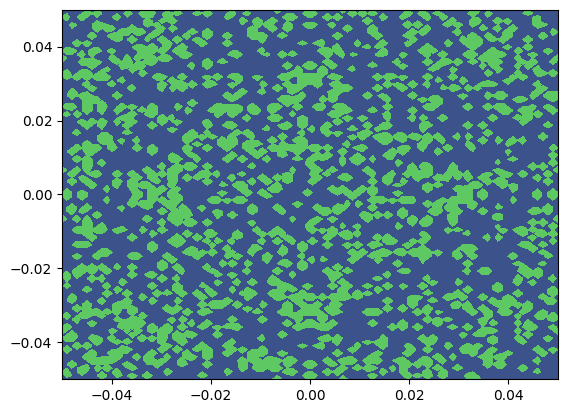

In [10]:
#plt.contourf(xx,yy,vx*xx+vy*yy)
#plt.contourf(xx,yy,vz)
plt.contourf(xx,yy,(xx*vy-yy*vx)/np.sqrt(xx**2+yy**2))
#plt.contourf(xx,yy,vy)


In [11]:
disc_vcoefs.Times()

[0.2]

In [12]:
# for the disc we get Cylindrical velocities

dv = disc_vcoef.getCoefs()
print(dv.shape)
# this can be recast into nfld by (lmax+1)*(lmax+2)/2 by nmax (for the spherical case)
lmax,nmax = 2,6
lindx = int((lmax+1))
reshaped_dv = dv.reshape(7,lindx,nmax)

# for the halo we get Spherical velocities
#v_r,v_phi,v_tan,v_r^2,v_phi^2,v_tan^2,weight,density

(126,)


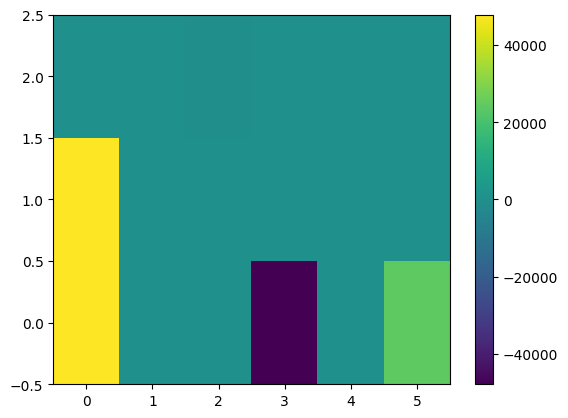

In [13]:
plt.imshow(np.real(reshaped_dv[0,:,:]), aspect='auto', interpolation='nearest',origin='lower')
plt.colorbar()

In [14]:
halo_vcoefs.Times()

[0.2]

In [15]:
# Now try some slices for rendering
#
rmax = 0.03
npix = 50

times = disc_vcoefs.Times()
pmin  = [-rmax, -rmax, 0.0]
pmax  = [ rmax,  rmax, 0.0]
grid  = [ npix,  npix,   0]

fields = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)

halo_surfaces = fields.slices(halo_vbasis, halo_vcoefs)
disc_surfaces = fields.slices(disc_vbasis, disc_vcoefs)


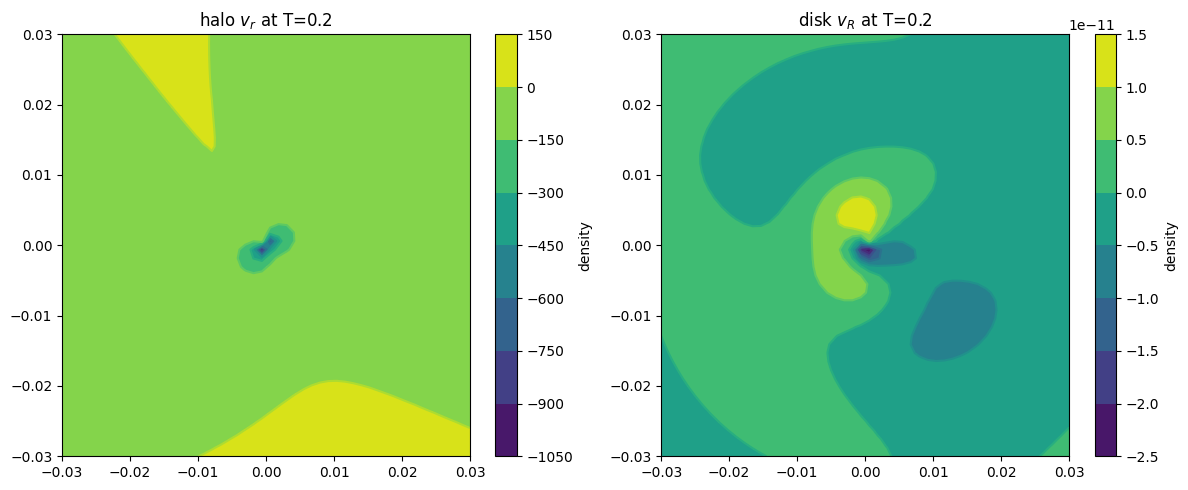

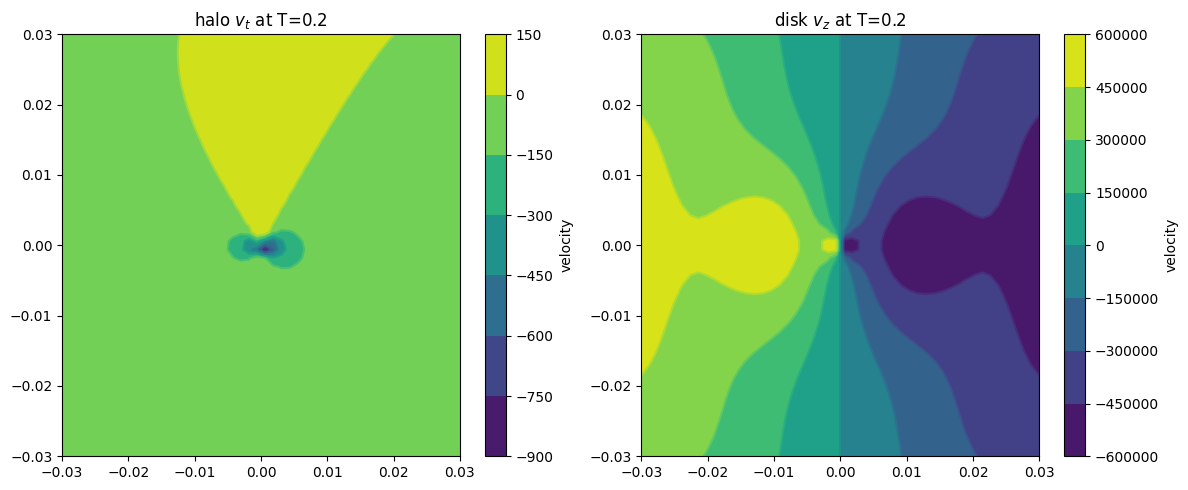

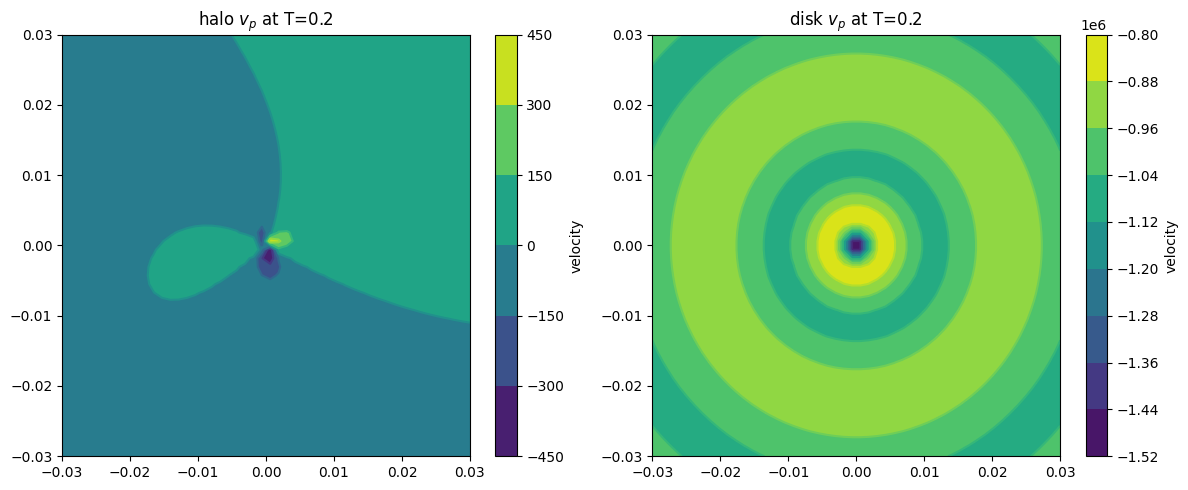

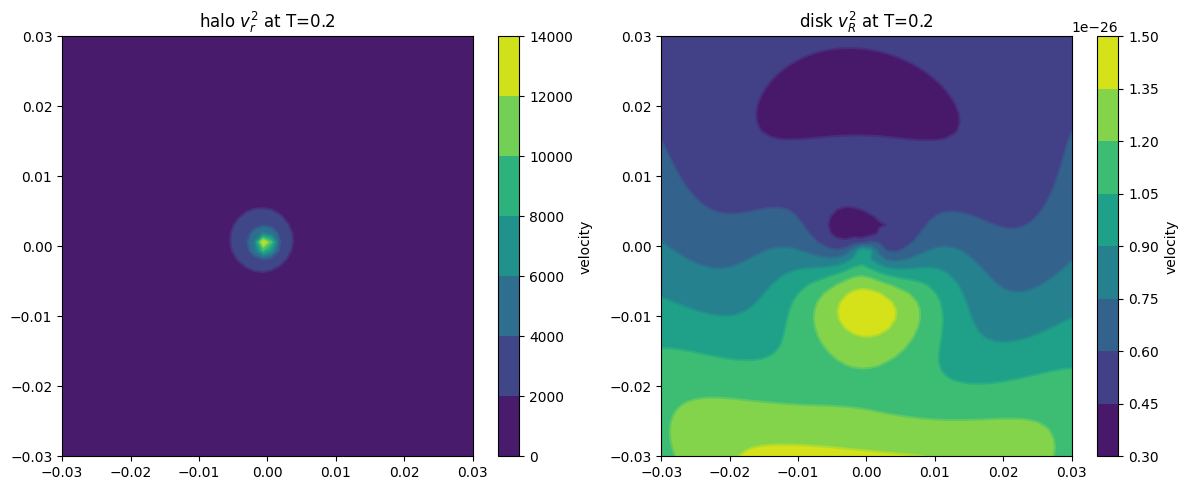

In [16]:

plt.rcParams['figure.figsize'] = [12, 5]

# Make the mesh
x = np.linspace(-rmax, rmax, npix)
y = np.linspace(-rmax, rmax, npix)
xv, yv = np.meshgrid(x, y)

import matplotlib.pyplot as plt
key = list(halo_surfaces.keys())[-1]

for i in range(1, 5):
    fig, ax = plt.subplots(1, 2)
    # Halo
    u = halo_vbasis.getFieldLabels()[i]
    wgt = 1.#halo_surfaces[key]['weight']
    ax[0].contour(xv, yv, halo_surfaces[key][u]/wgt)
    c1 = ax[0].contourf(xv, yv, halo_surfaces[key][u]/wgt)
    # Disk
    v = disc_vbasis.getFieldLabels()[i]
    wgt = 1.#disc_surfaces[key]['weight']
    ax[1].contour(xv, yv, disc_surfaces[key][v]/wgt)
    c2 = ax[1].contourf(xv, yv, disc_surfaces[key][v]/wgt)
    # Decoration
    ax[0].set_title(r'halo ${}$ at T={}'.format(u, key))
    ax[1].set_title(r'disk ${}$ at T={}'.format(v, key))
    if i==1:
        plt.colorbar(c1, ax=ax[0], label='density')
        plt.colorbar(c2, ax=ax[1], label='density')
    else:
        plt.colorbar(c1, ax=ax[0], label='velocity')
        plt.colorbar(c2, ax=ax[1], label='velocity')
    plt.tight_layout()
    plt.tight_layout()
    plt.show()


     

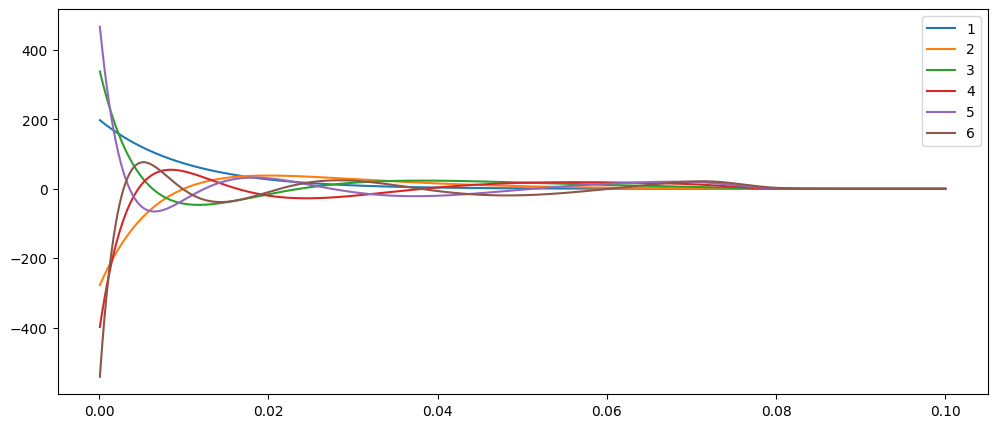

In [17]:
OF = np.loadtxt('fieldbasis_ortho.dump', skiprows=1)

for i in range(1, OF.shape[1]):
    plt.plot(OF[:,0], OF[:,i], label=str(i))

plt.legend()
plt.show()

(-0.01, 0.01)

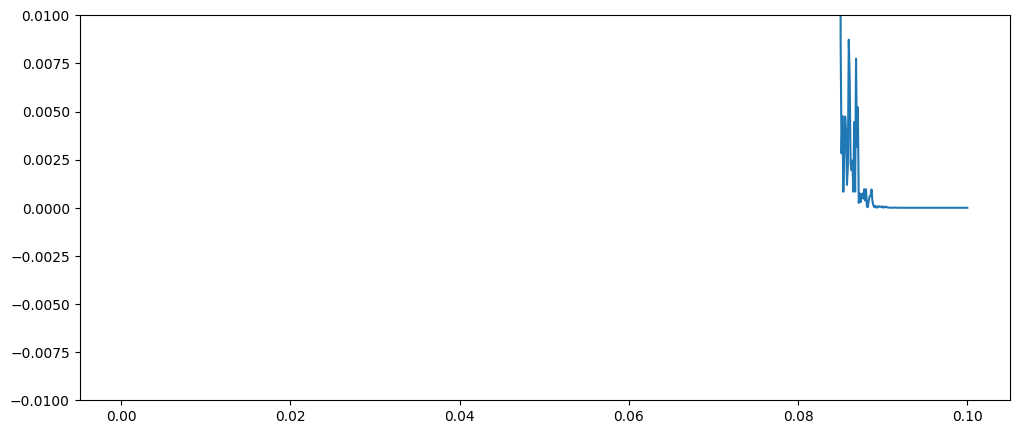

In [18]:
import pandas as pd
OF = pd.read_fwf('fieldbasis_ortho.dump',skiprows=1,header=None)
plt.plot(OF[0],(OF[1]))
plt.ylim(-0.01,0.01)

In [19]:
OF.keys()

Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')